In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)


Shape: (1500, 6)

Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

First 3 rows:


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0



Target class distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average message length : 12.7 words
Max message length     : 26 words
Min message length     : 7 words


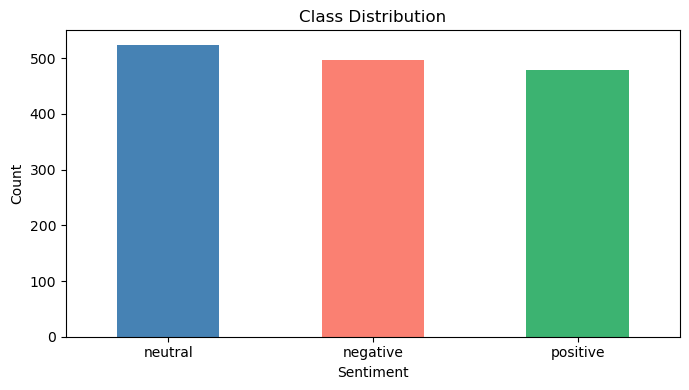


Sample messages:
  [NEUTRAL] I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  [POSITIVE] The refund process was fast and convenient. I appreciate the quick response.
  [NEGATIVE] My refund is still pending and this experience is frustrating. My ticket number is 33927.


In [4]:
df = pd.read_csv("C:/Users/Acer/Downloads/customer_support_text_classification.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
display(df.head(3))

print("\nTarget class distribution:")
print(df['sentiment_label'].value_counts())

print(f"\nAverage message length : {df['word_count'].mean():.1f} words")
print(f"Max message length     : {df['word_count'].max()} words")
print(f"Min message length     : {df['word_count'].min()} words")

# Plot class distribution
plt.figure(figsize=(7, 4))
df['sentiment_label'].value_counts().plot(kind='bar', color=['steelblue','salmon','mediumseagreen'])
plt.title('Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Sample messages
print("\nSample messages:")
for label in df['sentiment_label'].unique():
    msg = df[df['sentiment_label'] == label]['customer_message'].values[0]
    print(f"  [{label.upper()}] {msg}")

In [5]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                      # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)              # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)                    # remove special chars/numbers
    text = re.sub(r'\s+', ' ', text).strip()                # remove extra spaces
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS]      # remove stopwords
    return ' '.join(tokens)

df['clean_message'] = df['customer_message'].apply(clean_text)

print("Before:", df['customer_message'].iloc[0])
print("After :", df['clean_message'].iloc[0])

Before: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
After : need information payment process ticket number please respond soon possible


In [6]:
# Label encoding
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
df['label'] = df['sentiment_label'].map(label_map)

X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

Train: 1200  Test: 300
TF-IDF matrix shape: (1200, 427)


In [7]:
MAX_WORDS = 5000
MAX_LEN   = 30

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)

print(f"Padded sequence shape: {X_train_pad.shape}")

Padded sequence shape: (1200, 30)


In [8]:
lstm_model = models.Sequential([
    layers.Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),  # Embedding
    layers.LSTM(64, dropout=0.2),                                                 # LSTM
    layers.Dense(32, activation='relu'),                                          # Dense
    layers.Dense(3, activation='softmax')                                         # Output
])

lstm_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

lstm_model.summary()

history = lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test_cat),
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.3483 - loss: 1.0992 - val_accuracy: 0.3500 - val_loss: 1.0953
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6317 - loss: 0.7605 - val_accuracy: 0.9933 - val_loss: 0.1302
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9992 - loss: 0.0303 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 9.4900e-04
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9983 - loss: 0.0085 - val_accuracy: 0.9933 - val_loss: 0.0624
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9967 - loss: 0.0298 - val_accuracy: 0.9933 - val_loss: 0.0429
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9992 - loss: 0.0070 - val_accuracy: 1.0000

LSTM Test Accuracy: 1.0000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



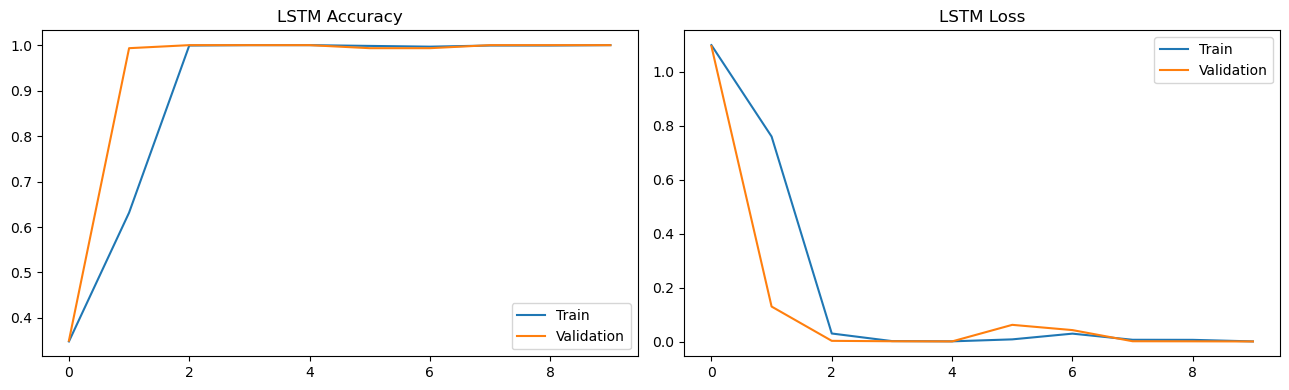

In [9]:
loss, acc = lstm_model.evaluate(X_test_pad, y_test_cat, verbose=0)
print(f"LSTM Test Accuracy: {acc:.4f}")

y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm,
      target_names=['negative', 'neutral', 'positive']))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('LSTM Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('LSTM Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
LABEL_NAMES = ['negative', 'neutral', 'positive']

sample_msgs = X_test.values[:5]
sample_true = y_test.values[:5]
sample_seqs = pad_sequences(tokenizer.texts_to_sequences(sample_msgs),
                            maxlen=MAX_LEN, padding='post')
sample_preds = np.argmax(lstm_model.predict(sample_seqs, verbose=0), axis=1)

print("Sample Predictions\n" + "="*60)
for msg, true, pred in zip(sample_msgs, sample_true, sample_preds):
    status = "yes" if true == pred else "no"
    print(f"{status} Message : {msg[:70]}")
    print(f"   Actual  : {LABEL_NAMES[true]}")
    print(f"   Predicted: {LABEL_NAMES[pred]}\n")

Sample Predictions
yes Message : like new payment easy use ticket number
   Actual  : positive
   Predicted: positive

yes Message : great service clear communication support team
   Actual  : positive
   Predicted: positive

yes Message : refund still pending experience frustrating
   Actual  : negative
   Predicted: negative

yes Message : app crashes whenever try use analytics
   Actual  : negative
   Predicted: negative

yes Message : response team helpful professional
   Actual  : positive
   Predicted: positive



## Task 6: Attention and Transformer Reflection

**Why do RNNs struggle with long-term dependencies?**
RNNs process text word by word and pass information through a hidden state. By the time it reaches the end of a long sentence, early words have been overwritten many times — the network effectively "forgets" them. This is called the vanishing gradient problem.

**How do LSTMs help?**
LSTMs add a "cell state" — a separate memory lane that runs alongside the hidden state. Three gates (input, forget, output) control what gets written, erased, or read from memory. This lets the model remember important information from much earlier in the sequence.

**What does Attention solve?**
Even LSTMs compress an entire sentence into one fixed-size vector before decoding. Attention allows the decoder to look back at **all** encoder states at every step and decide which words are most relevant right now. This removes the bottleneck and handles long sequences much better.

**Why are Transformers important in modern NLP and GenAI?**
Transformers replace recurrence entirely with **self-attention** — every word attends to every other word in parallel. This means:
- No sequential bottleneck → much faster to train on GPUs
- Better at capturing long-range relationships
- Scales to billions of parameters

Models like GPT, BERT, and Gemini are all transformer-based. They are the foundation of all modern generative AI — text generation, summarization, translation, and chatbots.